# OSRS NPC Classification -- Champion Model
# Evaluation

Local port of `04_eval.ipynb`, evaluating the champion checkpoint trained in
`03a_train_champion_local.ipynb`. Same eval suite as the original: classification report,
confusion matrix, sample predictions, Grad-CAM, filter visualization, activation maps, t-SNE.
Uses the shared `eval_utils.py` helpers so the challenger notebook (`04b`) and the comparison
notebook (`04c`) can reuse identical plotting/metric code.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt

from npc_data import load_clean_npc_df, add_top_class_labels, stratified_split, get_transforms, NPCDataset
import eval_utils as eu

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [2]:
df = load_clean_npc_df(data_dir="../data")
df, CLASS_NAMES, class_to_idx = add_top_class_labels(df, n=10)
train_df, val_df, test_df = stratified_split(df, seed=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

_, eval_transform = get_transforms(img_size=128)
test_loader = DataLoader(NPCDataset(test_df, eval_transform, data_dir="../data"), batch_size=32)

Train: 2421 | Val: 519 | Test: 519


In [3]:
class DualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = models.resnet18(weights="IMAGENET1K_V1")
        self.body_cnn = models.resnet18(weights="IMAGENET1K_V1")
        self.chathead_cnn.fc = nn.Identity()
        self.body_cnn.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        f1 = self.chathead_cnn(chathead)
        f2 = self.body_cnn(body)
        return self.classifier(torch.cat([f1, f2], dim=1))


model = DualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
model.load_state_dict(torch.load("../data/npc_classifier.pth", map_location=DEVICE))
model.eval()
print("Champion model loaded.")

Champion model loaded.


## Classification report

In [4]:
all_labels, all_preds, all_probs = eu.get_predictions(model, test_loader, DEVICE)
eu.print_classification_report(all_labels, all_preds, CLASS_NAMES)

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


              precision    recall  f1-score   support

       Human       0.86      0.92      0.89       314
       Dwarf       0.96      0.65      0.77        37
         Elf       1.00      0.64      0.78        22
       Gnome       0.89      0.76      0.82        21
     Vampyre       1.00      1.00      1.00         9
       Ghost       1.00      0.50      0.67         8
      Monkey       1.00      1.00      1.00         6
  Dorgeshuun       1.00      1.00      1.00         6
       Troll       1.00      1.00      1.00         5
         Cat       0.75      0.60      0.67         5
       Other       0.69      0.71      0.70        86

    accuracy                           0.84       519
   macro avg       0.92      0.80      0.84       519
weighted avg       0.85      0.84      0.84       519



## Confusion matrix

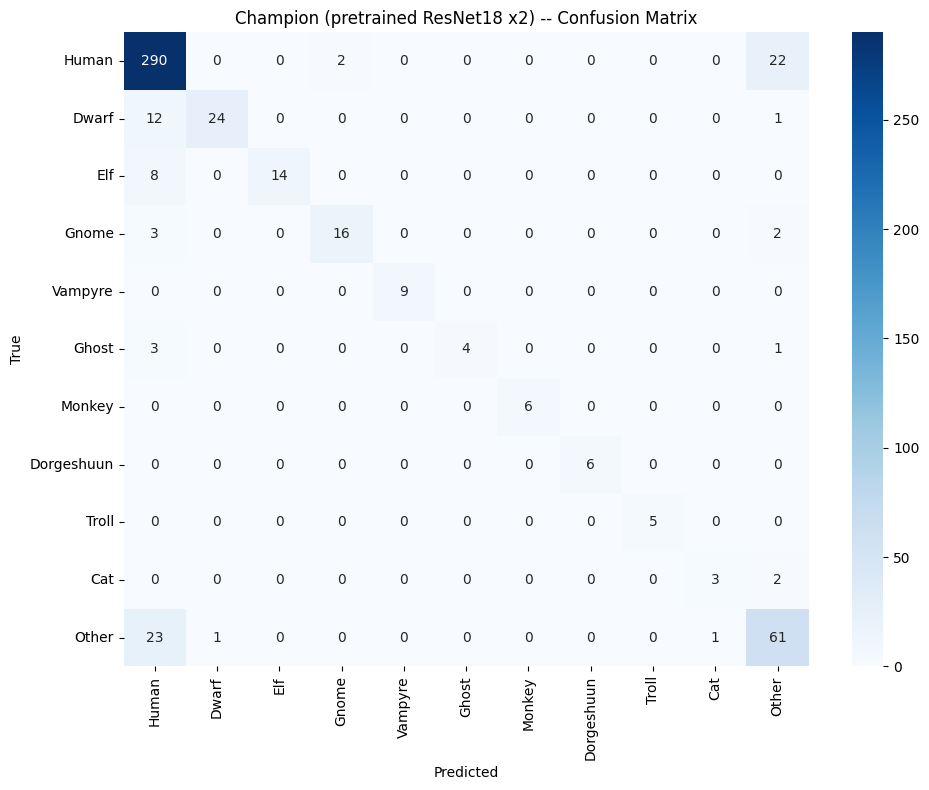

In [5]:
cm_champion = eu.plot_confusion_matrix(all_labels, all_preds, CLASS_NAMES, title="Champion (pretrained ResNet18 x2) -- Confusion Matrix", save_path="../img/champion_confusion_matrix.png")

## Sample predictions

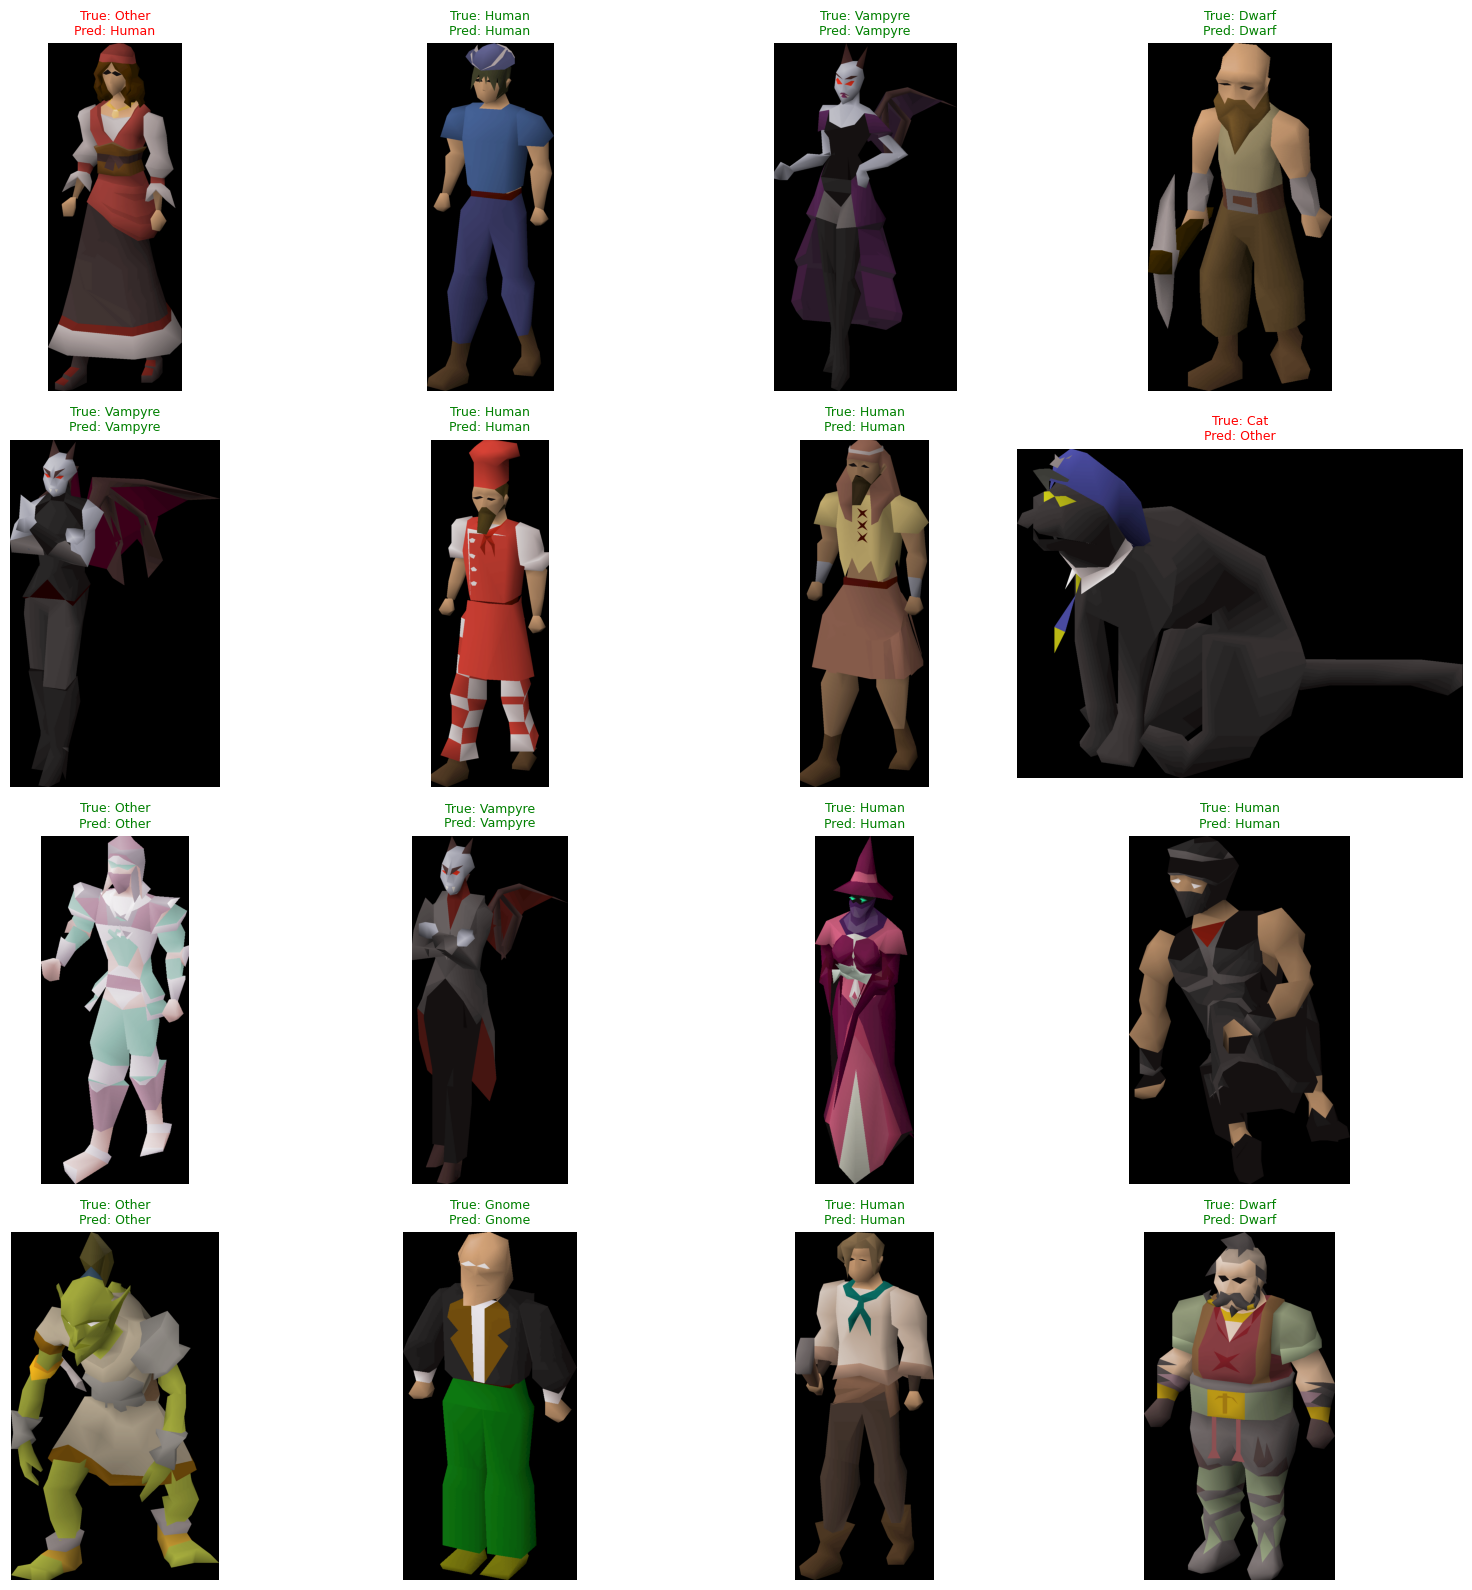

In [6]:
eu.predictions_grid(model, test_df, CLASS_NAMES, eval_transform, "../data", DEVICE, n=16, save_path="../img/champion_predictions_sample.png")

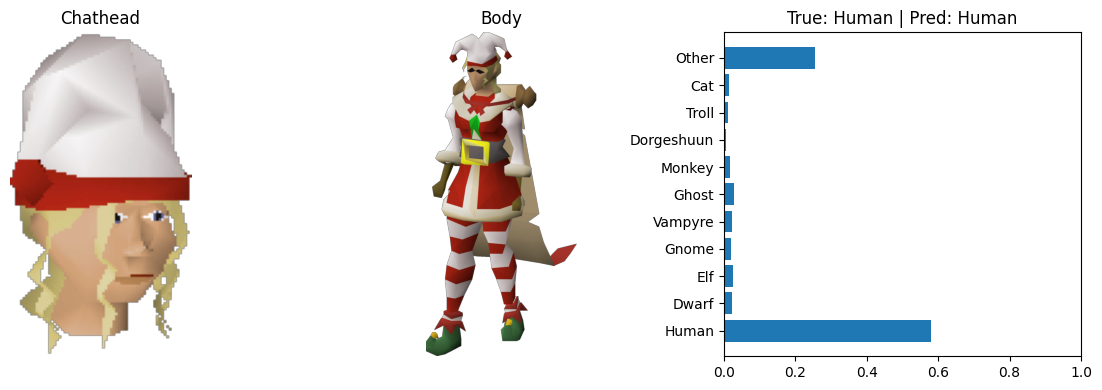

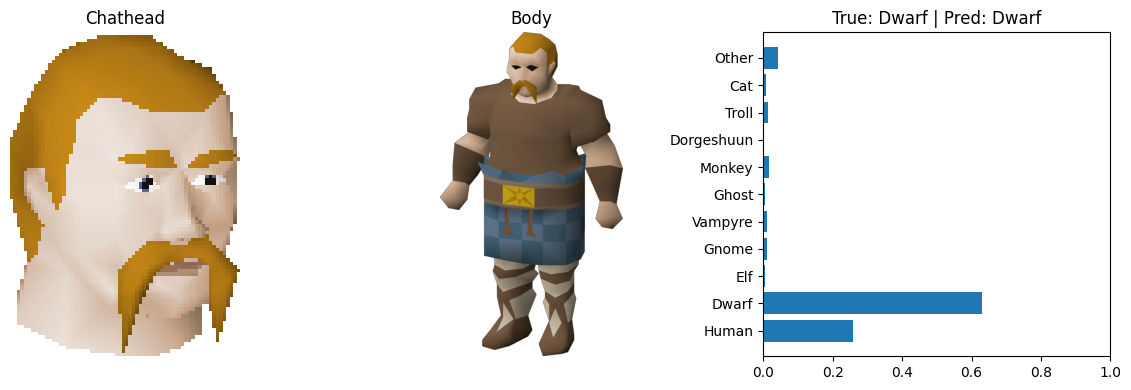

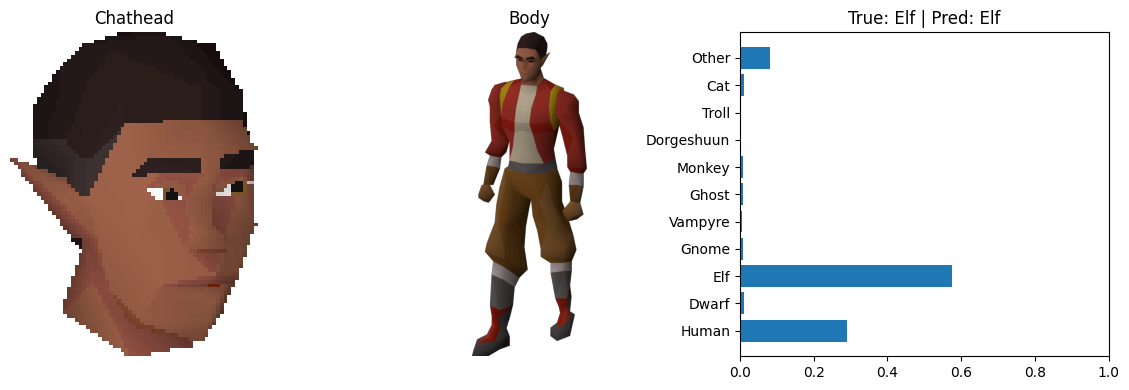

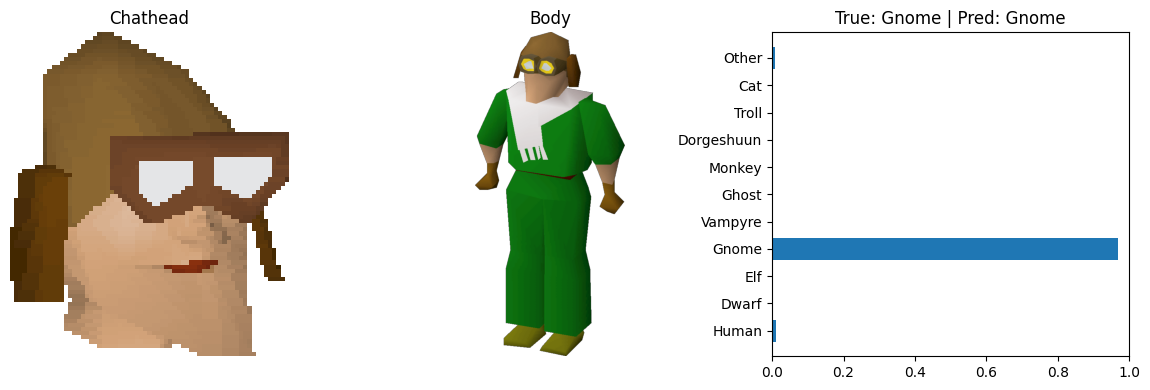

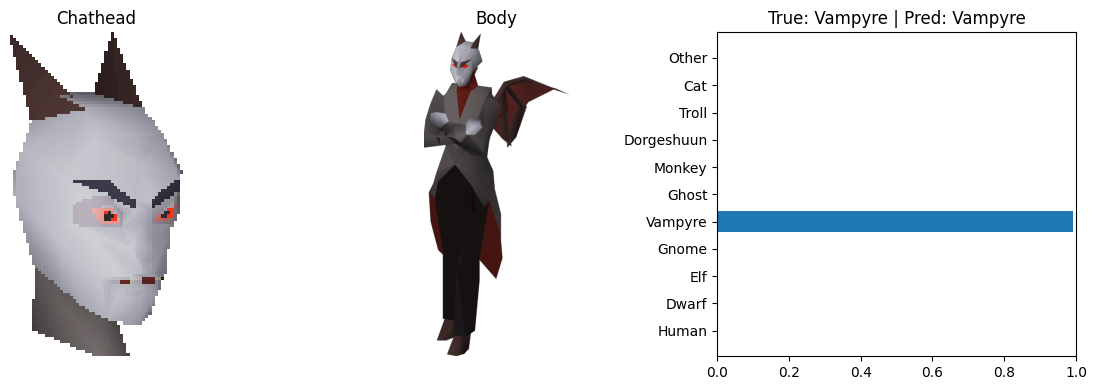

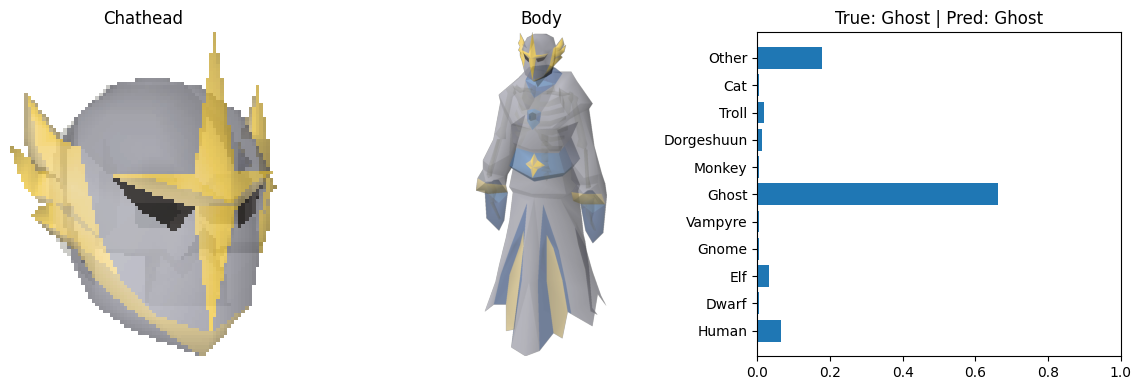

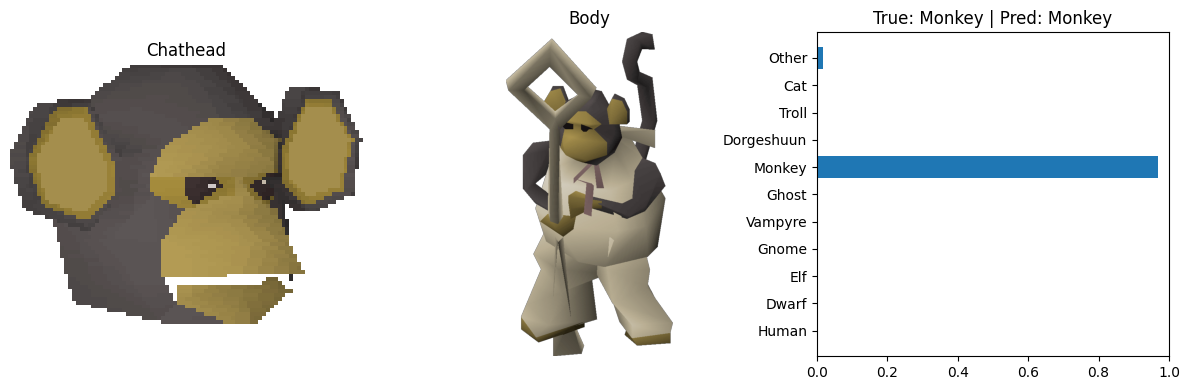

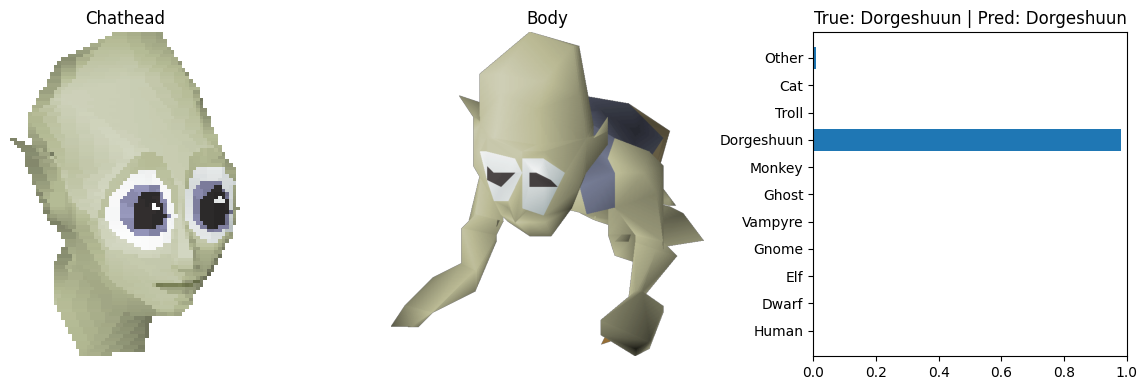

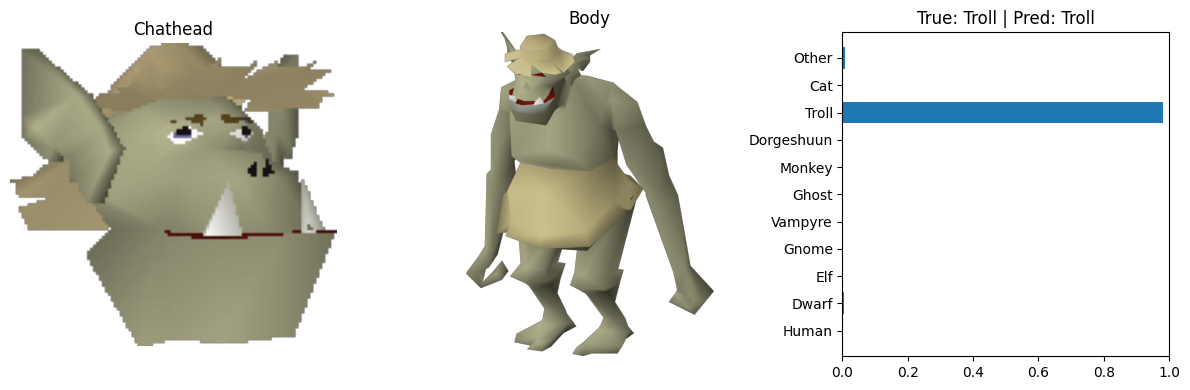

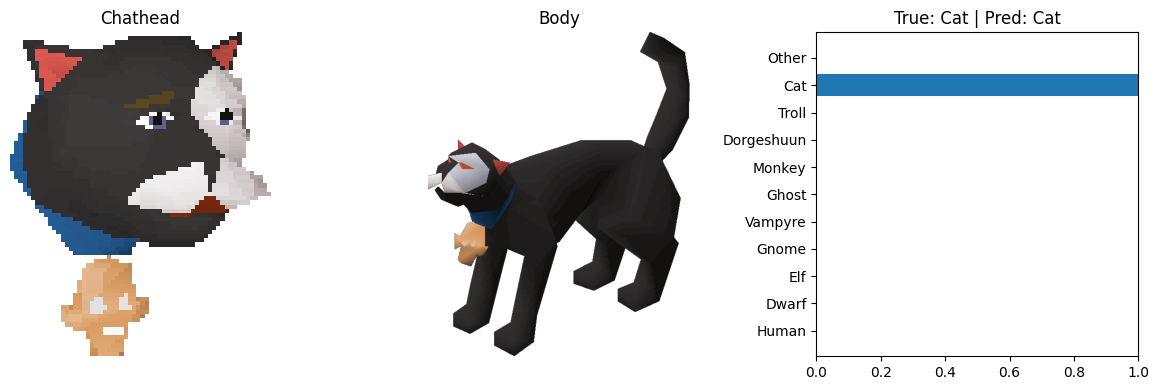

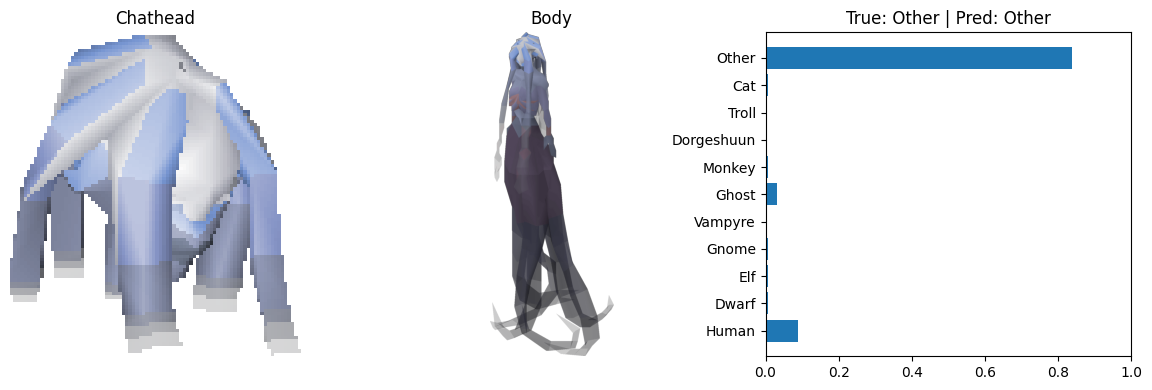

In [7]:
for cls in CLASS_NAMES:
    eu.show_prediction(model, test_df, cls, CLASS_NAMES, eval_transform, "../data", DEVICE)

## Grad-CAM

Shows which pixels the model paid the most attention to at each ResNet18 stage (layer1 = edges,
layer2 = textures, layer3 = parts, layer4 = high-level concepts).

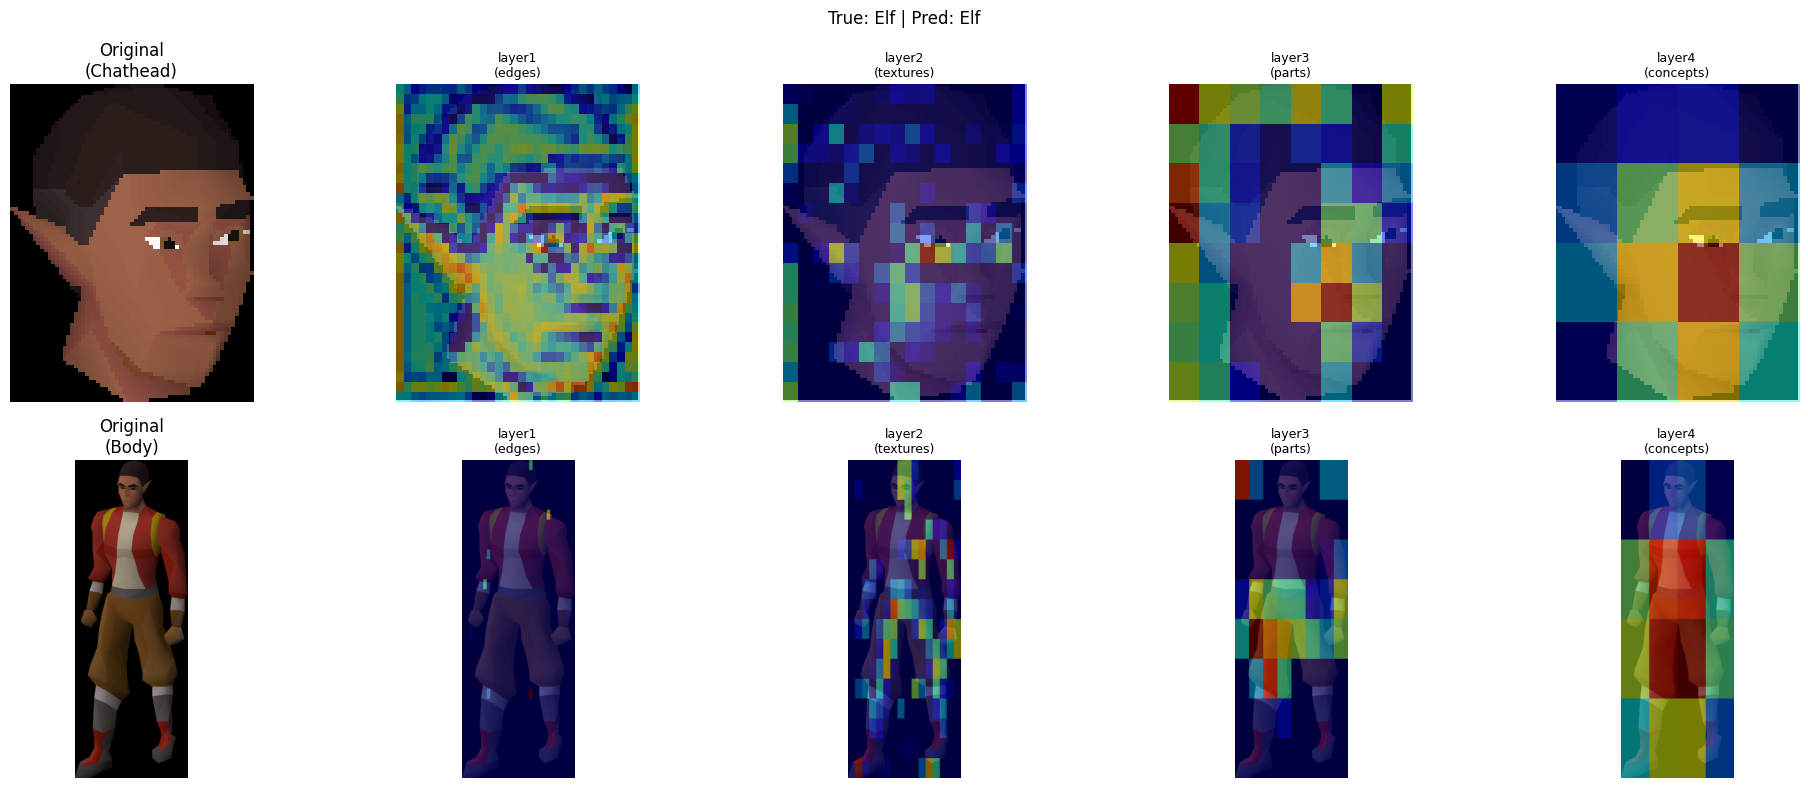

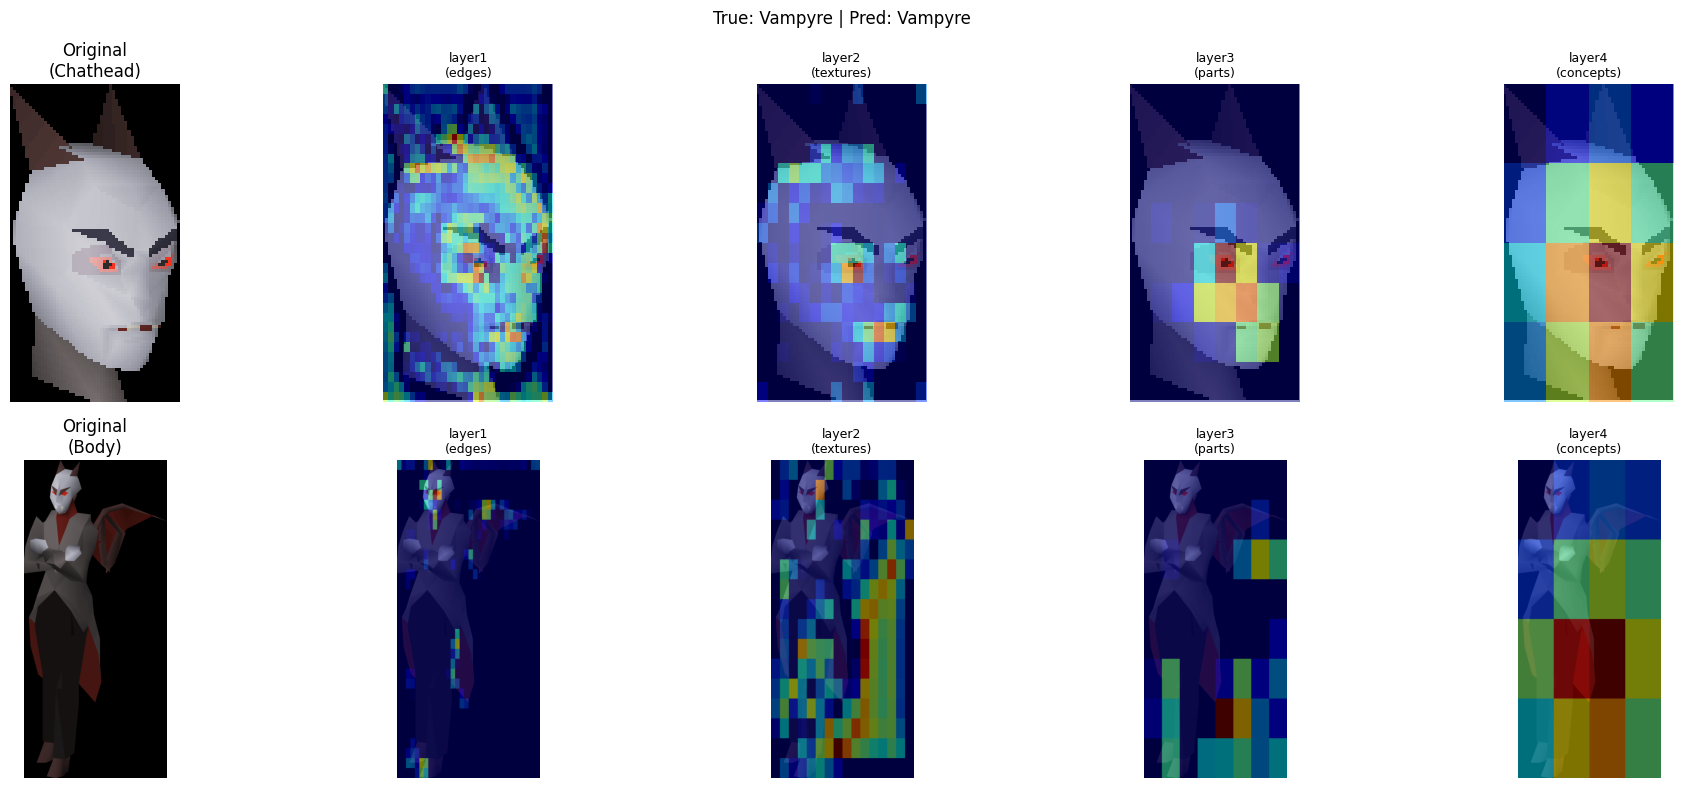

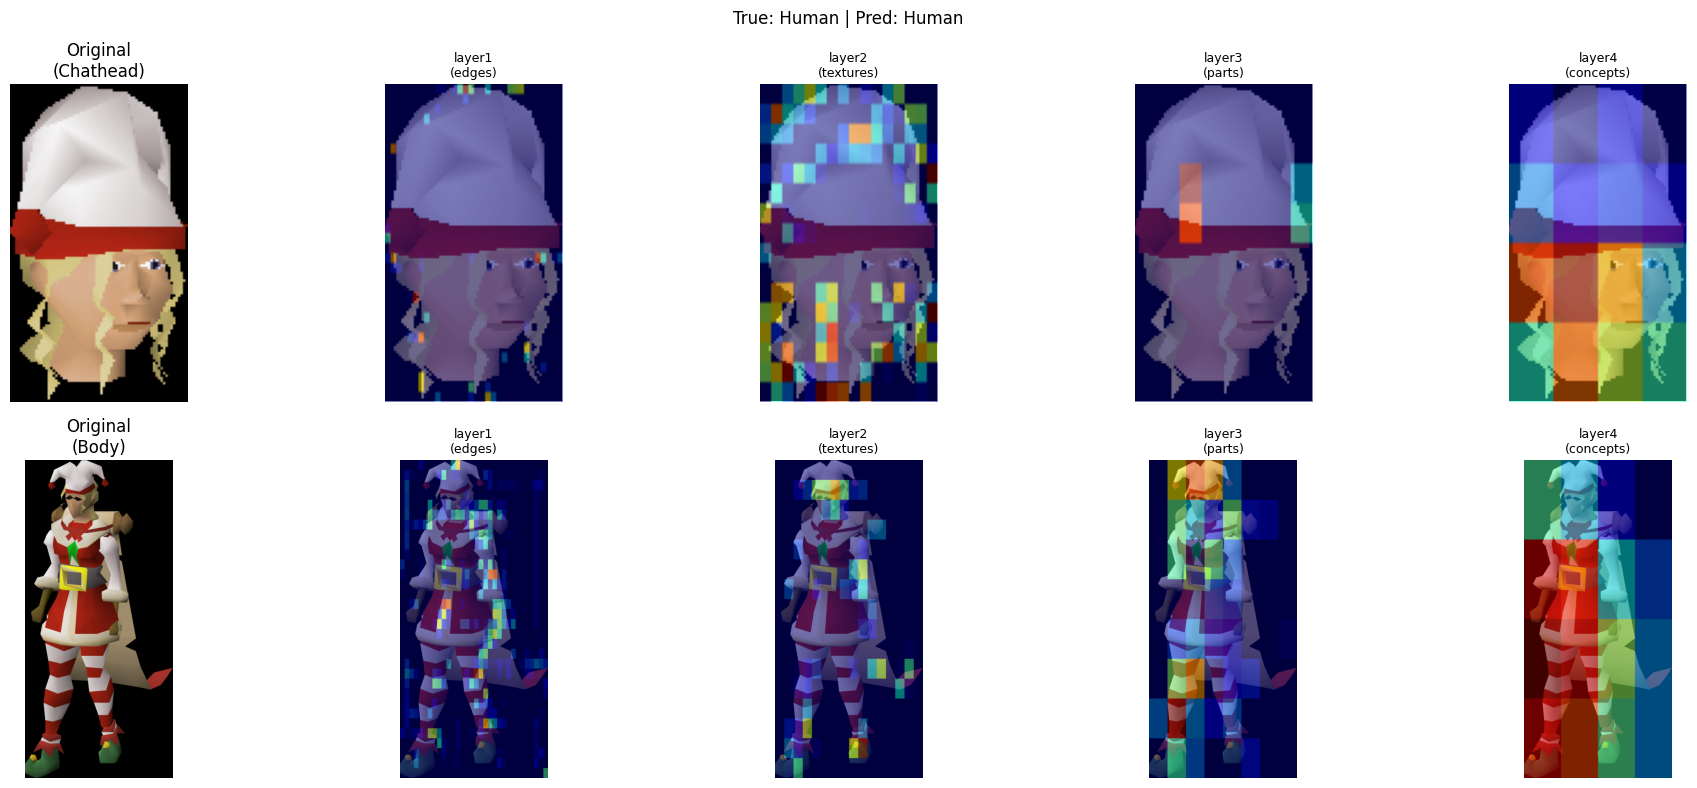

In [8]:
CHATHEAD_LAYERS = [
    (model.chathead_cnn.layer1, "layer1\n(edges)"),
    (model.chathead_cnn.layer2, "layer2\n(textures)"),
    (model.chathead_cnn.layer3, "layer3\n(parts)"),
    (model.chathead_cnn.layer4, "layer4\n(concepts)"),
]
BODY_LAYERS = [
    (model.body_cnn.layer1, "layer1\n(edges)"),
    (model.body_cnn.layer2, "layer2\n(textures)"),
    (model.body_cnn.layer3, "layer3\n(parts)"),
    (model.body_cnn.layer4, "layer4\n(concepts)"),
]

for cls in ["Elf", "Vampyre", "Human"]:
    eu.show_grad_cam(model, test_df, cls, CLASS_NAMES, eval_transform, "../data", DEVICE, CHATHEAD_LAYERS, BODY_LAYERS, seed=42)

## Filter visualization -- layer1 of the body backbone

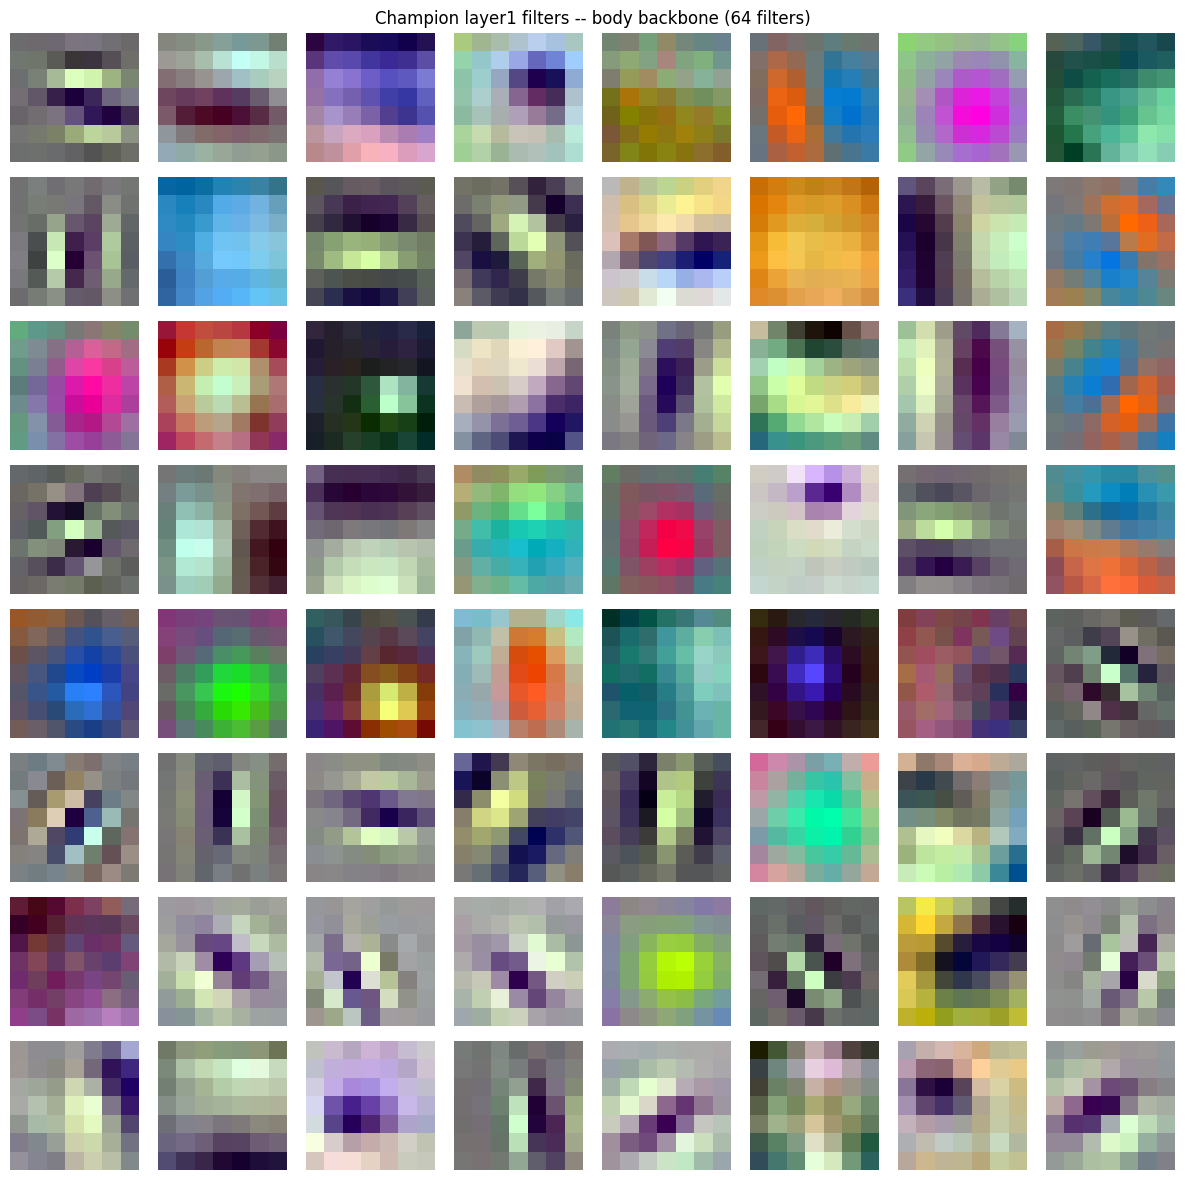

In [9]:
filters = model.body_cnn.conv1.weight.detach().cpu()

def normalize_filter(f):
    f = f - f.min()
    return f / (f.max() + 1e-8)

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(normalize_filter(filters[i]).permute(1, 2, 0))
    ax.axis("off")
plt.suptitle("Champion layer1 filters -- body backbone (64 filters)", fontsize=12)
plt.tight_layout()
plt.show()

## t-SNE of learned body-branch features (test set)

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


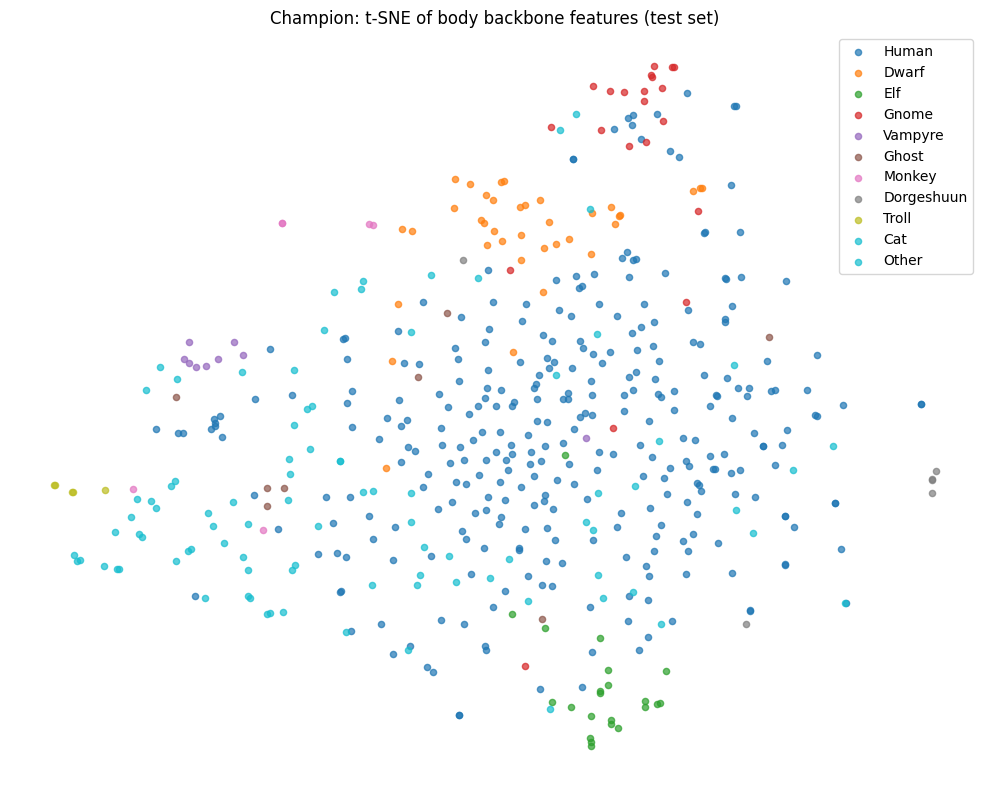

In [10]:
eu.tsne_of_body_features(model, test_loader, DEVICE, CLASS_NAMES, "Champion: t-SNE of body backbone features (test set)", save_path="../img/champion_tsne.png")